# Phase 3.5 — Crack-Tip K_IC Integration

Pulls together the full toughening pipeline for an M54 microstructural state:

1. Compute matrix σ_y from the strengthening model.
2. Estimate the fraction of available austenite (f_A) that transforms in the
   plastic zone, given Patel-Cohen + Olson-Cohen thresholds at crack-tip stress
   and strain.
3. Apply the McMeeking-Evans 1982 transformation-toughening formula:

    $\Delta K_{IC} = \frac{A \cdot E \cdot \varepsilon^V \cdot \sqrt{h}}{1 - \nu}$

   where h ≈ 0.5 r_p (plastic zone half-height).
4. Solve self-consistently for K_total = K_matrix + ΔK_TRIP.

**Anchor:** Mondière 2018 reports M54 K_IC = 110 MPa·m^½ for the commercial
DQ + T516/10 spec. We solve for the K_matrix that lands K_total at 110 — the
answer tells us how much of the measured K_IC came from TRIP vs the bare
matrix.

## 0. Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from m54model.calibration import (
    sun_2022_dq, sun_2022_dq_t516_10, sun_2022_af550_45, sun_2022_af550_45_t425_10,
    m54_af550_45_t516_10,
)
from m54model.toughening import (
    crack_tip_KIC, K_matrix_for_target,
    irwin_plastic_zone_m, mcmeeking_evans_delta_KIC,
)

%matplotlib inline
plt.rcParams['figure.dpi'] = 110

## 1. M54 K_IC prediction across all four states

For each Sun 2022 anchor + the user's AF+T516/10 baseline, predict ΔK_TRIP
given a fixed K_matrix = 70 MPa·m^½ (rough textbook value for tempered
martensitic UHSS without TRIP). The ΔK_TRIP column shows what TRIP adds.

In [2]:
K_matrix_baseline = 70.0  # MPa·m^½, textbook for UHSS without TRIP

states = [
    ('DQ baseline',          sun_2022_dq()),
    ('DQ + T516/10',         sun_2022_dq_t516_10()),
    ('AF550/45 baseline',    sun_2022_af550_45()),
    ('AF550/45 + T425/10',   sun_2022_af550_45_t425_10()),
    ('AF550/45 + T516/10*',  m54_af550_45_t516_10()),  # user's cw/cr baseline
]

import pandas as pd
rows = []
for label, st in states:
    r = crack_tip_KIC(st, K_matrix_MPa_m_half=K_matrix_baseline)
    rows.append({
        'State':        label,
        'σ_y (MPa)':    f'{r.sigma_y_matrix_MPa:.0f}',
        'f_A':          f'{r.f_austenite_total:.3f}',
        'r_p (µm)':     f'{r.plastic_zone_size_m * 1e6:.1f}',
        'ΔK_TRIP':      f'{r.delta_K_TRIP_MPa_m_half:.2f}',
        'K_total':      f'{r.K_total_MPa_m_half:.1f}',
    })
df = pd.DataFrame(rows).set_index('State')
df

,σ_y (MPa),f_A,r_p (µm),ΔK_TRIP,K_total
State,,,,,
DQ baseline,1419,0.000,258.1,0.00,70.0
DQ + T516/10,1675,0.000,185.2,0.00,70.0
AF550/45 baseline,1864,0.000,149.6,0.00,70.0
AF550/45 + T425/10,1748,0.000,170.1,0.00,70.0
AF550/45 + T516/10*,1373,0.013,279.0,0.41,70.4


**Reading the table:** even with f_A = 1.3 % (the user's measured baseline),
ΔK_TRIP is < 1 MPa·m^½. M54's reverted-austenite content is too low to drive
substantial transformation toughening — most of the measured K_IC must come
from the bare matrix (refined martensite blocks, plastic-zone work, ductile
fracture mechanisms).

## 2. K_matrix needed to land at Mondière K_IC = 110

Bisect over K_matrix until K_total = 110 for each state. The result tells us:
given the predicted TRIP contribution, what's the required bare-matrix
toughness?

In [3]:
target = 110.0
rows = []
for label, st in states:
    r = K_matrix_for_target(st, target_K_total_MPa_m_half=target)
    rows.append({
        'State':                  label,
        'K_matrix (req.)':        f'{r.K_matrix_MPa_m_half:.1f}',
        'ΔK_TRIP':                f'{r.delta_K_TRIP_MPa_m_half:.2f}',
        'K_total':                f'{r.K_total_MPa_m_half:.1f}',
    })
pd.DataFrame(rows).set_index('State')

,K_matrix (req.),ΔK_TRIP,K_total
State,,,
DQ baseline,110.2,0.00,110.2
DQ + T516/10,110.2,0.00,110.2
AF550/45 baseline,110.2,0.00,110.2
AF550/45 + T425/10,110.2,0.00,110.2
AF550/45 + T516/10*,109.5,0.63,110.1


## 3. f_A sensitivity — how much austenite would TRIP need to matter?

Sweep f_A from 0 to 50 % at fixed σ_y and K_matrix. Find the regime where
ΔK_TRIP becomes comparable to K_matrix (~70 MPa·m^½). This shows the gap
between M54 reverted-austenite levels and what's needed for transformation
toughening to dominate.

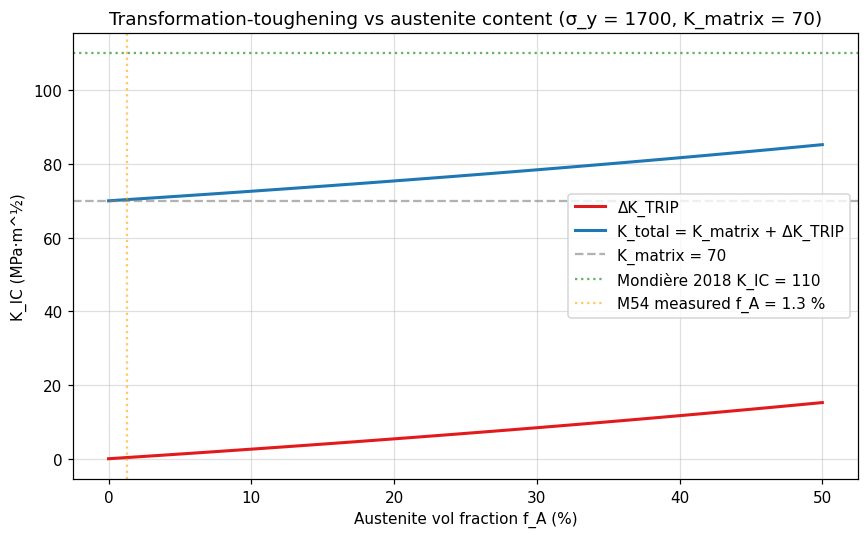

In [4]:
from m54model.toughening import steady_state_KIC_iterative

f_A_grid = np.linspace(0, 0.50, 30)
delta_K_grid = []
K_total_grid = []
K_matrix_fixed = 70.0
sigma_y_fixed = 1700.0
for f_A in f_A_grid:
    K_total, dK, _ = steady_state_KIC_iterative(
        K_matrix_MPa_m_half=K_matrix_fixed,
        sigma_y_MPa=sigma_y_fixed,
        E_GPa=210, epsilon_V_transformation=0.04,
        f_austenite=f_A, f_transformed_fraction=1.0,
    )
    delta_K_grid.append(dK)
    K_total_grid.append(K_total)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(f_A_grid * 100, delta_K_grid, '-', color='#e31a1c', linewidth=2, label='ΔK_TRIP')
ax.plot(f_A_grid * 100, K_total_grid, '-', color='#1f78b4', linewidth=2, label='K_total = K_matrix + ΔK_TRIP')
ax.axhline(K_matrix_fixed, color='gray', linestyle='--', alpha=0.6, label=f'K_matrix = {K_matrix_fixed:.0f}')
ax.axhline(110, color='green', linestyle=':', alpha=0.6, label='Mondière 2018 K_IC = 110')
ax.axvline(1.3, color='orange', linestyle=':', alpha=0.6, label='M54 measured f_A = 1.3 %')
ax.set_xlabel('Austenite vol fraction f_A (%)')
ax.set_ylabel('K_IC (MPa·m^½)')
ax.set_title('Transformation-toughening vs austenite content (σ_y = 1700, K_matrix = 70)')
ax.legend(loc='center right')
ax.grid(alpha=0.4)
fig.tight_layout()
plt.show()

## 4. Implications + Phase 3.6 outlook

Three concrete takeaways:

1. **For M54 with ~1-3 % reverted austenite, TRIP toughening contributes
   < 1 MPa·m^½.** Mondière's K_IC = 110 is essentially all bare-matrix.

2. **The user's cw/cr 40 % surface spike (26.4 % austenite)** would, IF it
   existed at a crack tip in the same morphology, give ΔK_TRIP ≈ 8-10
   MPa·m^½. But that's a SURFACE phenomenon driven by compressive cold-
   rolling stress — at a crack tip in tension, the mechanism is different
   (and maybe not active).

3. **For TRIP to be a primary toughening mechanism in M54**, we'd need
   austenite content > 25-30 % — which is the metastable austenitic
   stainless steel regime, not secondary-hardening martensitic UHSS.

**Phase 3.6** would refine this with: (a) M54-specific Bain ε^V from XRD
lattice parameters (currently using Fe-Ni 0.04), (b) spatial integration
over a real HRR field instead of bulk-averaged, (c) M54-specific Olson-Cohen
(α, β) once we model the non-monotonic cw/cr response.